# Feature Evaluation - US Firm Characteristics

Evaluation of Ch8 financial features against 1-month forward returns.
Produces triage decisions for Ch11 modeling.

**Learning Objectives**:
- Evaluate 57 financial features with HAC-adjusted IC
- Apply Benjamini-Hochberg FDR to control false discovery across the factor zoo
- Assess quantile monotonicity and fold-level stability (10 walk-forward folds)
- Produce a triage ledger (PROCEED / REVISE / STOP) for Ch11 model selection

**Book Reference**: Chapter 7, Section 7.3 (Univariate feature-label evaluation)
and Section 7.4 (Search accounting and multiple testing). Chapter 8.6 is the
secondary reference for search control.

**Prerequisites**: Run `03_financial_features.py` first.

In [1]:
"""Feature Evaluation - US Firm Characteristics

Evaluation of Ch8 financial features against forward return labels.
Produces triage decisions for Ch11 modeling.
"""

import json
from datetime import date

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from ml4t.diagnostic.evaluation.stats import benjamini_hochberg_fdr
from ml4t.diagnostic.metrics import compute_ic_hac_stats, compute_ic_uncertainty
from scipy.stats import spearmanr

from utils.paths import display_path, get_case_study_dir
from utils.style import COLORS, FIGSIZE, add_message_title, zero_line

In [2]:
# Production defaults
MAX_SYMBOLS = 0

## Configuration

Every threshold the screens, the triage rule and the figure subtitles refer to is
bound once here. A threshold retyped into a markdown table is a second source of
truth for a decision the code has already made, and it is how a table comes to
describe a rule the notebook stopped applying.

In [3]:
CASE_STUDY_ID = "us_firm_characteristics"
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
EVAL_DIR = CASE_DIR / "evaluation"
EVAL_DIR.mkdir(exist_ok=True)

MIN_COVERAGE = 0.70  # non-null share a feature needs before it is evaluated at all
FDR_ALPHA = 0.05  # Benjamini-Hochberg level
REDUNDANCY_CUT = 0.7  # |rho| above which two features are reported as one piece of evidence
MIN_SIGN_CONSISTENCY = 0.60  # fold-sign agreement the exploration arm requires
LABEL_HORIZON_MONTHS = 1  # fwd_ret_1m resolves in one month-end step, so ICs do not overlap
IC_THRESHOLD = 0.01  # |IC| the exploration arm requires, at a monthly rebalance
N_QUANTILES = 5
HAC_MAXLAGS = 4  # monthly IC series; the label resolves in one step, so this is the safe side

# The minimum cross-section is derived from the universe actually loaded rather than
# typed, so a reduced CI run shrinks the gate with it. Typed, the gate exceeds the
# reduced cross-section and every statistic below is computed on an empty feature set
# while the test still passes.
MIN_CROSS_SECTION = 30
MIN_PERIODS = MIN_CROSS_SECTION if MAX_SYMBOLS == 0 else min(MIN_CROSS_SECTION, MAX_SYMBOLS)

## Section 0: Load Artifacts

Load pre-computed financial features and labels, then build
the evaluation panel.

In [4]:
# Load features
features = pl.read_parquet(CASE_DIR / "features" / "financial.parquet")

# Load primary label
PRIMARY_LABEL_FILE = "fwd_ret_1m.parquet"
label_df = pl.read_parquet(CASE_DIR / "labels" / PRIMARY_LABEL_FILE)

# Auto-detect label column
label_col = [c for c in label_df.columns if c not in ("timestamp", "symbol")][0]

# Load CV config for fold-level analysis
with open(CASE_DIR / "config" / "cv_config.json") as f:
    cv_config = json.load(f)

# The corrected converter preserves the anonymous firm axis within the source block.
JOIN_COLS = ["timestamp", "symbol"]
DATE_COL = "timestamp"
HOLDOUT_START = date.fromisoformat(cv_config["holdout_start"])

In [5]:
# Identify feature columns
financial_cols = [c for c in features.columns if c not in JOIN_COLS]
all_feature_cols = financial_cols

# Build the full panel, then seal the holdout from every diagnostic and decision.
full_panel = features.join(label_df, on=JOIN_COLS, how="inner", validate="1:1")
assert len(full_panel) == len(features) == len(label_df)
eval_panel = full_panel.filter(pl.col(DATE_COL) < HOLDOUT_START)

# Optional: reduce universe for fast dev (Papermill parameter)
if MAX_SYMBOLS > 0:
    top = eval_panel.group_by("symbol").len().sort("len", descending=True).head(MAX_SYMBOLS)
    eval_panel = eval_panel.filter(pl.col("symbol").is_in(top["symbol"]))

n_rows = len(eval_panel)
n_symbols_avg = (
    eval_panel.group_by(DATE_COL).agg(pl.col("symbol").n_unique()).select("symbol").mean().item()
)
n_dates = eval_panel[DATE_COL].n_unique()
print(
    f"Pre-holdout panel: {n_rows:,} rows, ~{n_symbols_avg:.0f} stocks/month avg, {n_dates} months"
)
print(f"Sealed holdout: {len(full_panel) - len(eval_panel):,} rows from {HOLDOUT_START}")
print(f"Features: {len(financial_cols)} financial")
print(f"Label: {label_col}")

Pre-holdout panel: 780,882 rows, ~2503 stocks/month avg, 312 months
Sealed holdout: 23,648 rows from 2016-01-01
Features: 57 financial
Label: fwd_ret_1m


## Data Quality Gate

Verify upstream artifacts are free of critical defects before evaluation.

In [6]:
from utils.data_quality import validate_modeling_inputs

validate_modeling_inputs(
    features_df=eval_panel,
    label_df=eval_panel,
    feature_cols=all_feature_cols,
    label_col=label_col,
    join_cols=JOIN_COLS,
    asset_col="symbol",
    max_abs_return=20.0,  # 1-month returns (max observed ~19.0, small caps)
    fail_on_critical=True,
)

Data Quality Gate: ALL CLEAR


{'issues': [], 'n_critical': 0, 'n_warning': 0}

## Section 1: Correctness Screens

Check coverage before evaluating predictive power. Features whose non-null share
falls below `MIN_COVERAGE` are flagged. The released characteristics deliberately update at
different frequencies, so repeated values can be economically correct rather
than a stale-feed defect. The persistent identifier nevertheless lets downstream
models construct valid longitudinal histories.

In [7]:
# Coverage: fraction non-null per feature
coverage = {}
for feat in all_feature_cols:
    n_valid = eval_panel[feat].drop_nulls().len()
    coverage[feat] = n_valid / n_rows

# Correctness gate: coverage at or above MIN_COVERAGE.
correctness = {feat: coverage[feat] >= MIN_COVERAGE for feat in all_feature_cols}

n_pass = sum(correctness.values())
n_fail = len(correctness) - n_pass
print(f"Correctness gate: {n_pass} PASS, {n_fail} FAIL (coverage-only)")
print(f"Persistent anonymous firms in development panel: {eval_panel['symbol'].n_unique():,}")

if n_fail > 0:
    fail_df = pl.DataFrame(
        {
            "feature": [f for f, ok in correctness.items() if not ok],
            "coverage": [coverage[f] for f, ok in correctness.items() if not ok],
        }
    )
    print(fail_df)

Correctness gate: 57 PASS, 0 FAIL (coverage-only)
Persistent anonymous firms in development panel: 9,793


## Section 2: Univariate Association (IC + HAC)

For each feature, compute a time series of cross-sectional Spearman IC - one per
month, across the cross-section printed above - then test significance with HAC
standard errors over `HAC_MAXLAGS` lags of the monthly series.

In [8]:
evaluable_features = [f for f in all_feature_cols if correctness[f]]

# Detect date-level features (zero cross-sectional variance)
cs_std_df = eval_panel.group_by(DATE_COL).agg(
    [pl.col(f).std().alias(f) for f in evaluable_features]
)
date_level_features = set()
for feat in evaluable_features:
    mean_std = cs_std_df[feat].drop_nulls().mean()
    if mean_std is not None and mean_std < 1e-10:
        date_level_features.add(feat)

if date_level_features:
    print(f"Date-level features (zero CS variance): {sorted(date_level_features)}")

In [9]:
# Batch IC computation: one pass over months, all features at once
cs_features = [f for f in evaluable_features if f not in date_level_features]
cols_needed = [DATE_COL] + cs_features + [label_col]
eval_sub = eval_panel.select(cols_needed).drop_nulls(subset=[label_col])

dates_list = eval_sub[DATE_COL].unique().sort().to_list()
n_total = len(dates_list)

ic_series_data = {feat: [] for feat in cs_features}

for i, dt in enumerate(dates_list):
    cross_section = eval_sub.filter(pl.col(DATE_COL) == dt)
    n_obs = len(cross_section)
    if n_obs < MIN_PERIODS:
        continue

    label_arr = cross_section[label_col].to_numpy()
    label_valid = ~np.isnan(label_arr)

    for feat in cs_features:
        feat_arr = cross_section[feat].to_numpy()
        valid_mask = label_valid & ~np.isnan(feat_arr)
        n_valid = int(valid_mask.sum())
        if n_valid >= MIN_PERIODS:
            ic_val, _ = spearmanr(feat_arr[valid_mask], label_arr[valid_mask])
            if not np.isnan(ic_val):
                ic_series_data[feat].append((dt, float(ic_val), n_valid))

    if (i + 1) % 50 == 0:
        print(f"  IC progress: {i + 1}/{n_total} months")

print(f"  IC progress: {n_total}/{n_total} months (done)")

  IC progress: 50/312 months


  IC progress: 100/312 months


  IC progress: 150/312 months


  IC progress: 200/312 months


  IC progress: 250/312 months


  IC progress: 300/312 months


  IC progress: 312/312 months (done)


In [10]:
# Convert to DataFrames and compute HAC stats
ic_results = {}
ic_timeseries = {}
for feat in cs_features:
    data = ic_series_data[feat]
    if len(data) < 20:
        continue
    dates_f, ics_f, nobs_f = zip(*data, strict=False)
    ic_df = pl.DataFrame({DATE_COL: list(dates_f), "ic": list(ics_f), "n_obs": list(nobs_f)})
    hac_stats = compute_ic_hac_stats(ic_df, ic_col="ic", maxlags=HAC_MAXLAGS)
    ic_results[feat] = hac_stats
    ic_timeseries[feat] = ic_df

print(f"IC computed for {len(ic_results)} cross-sectional features")
print(f"Skipped {len(date_level_features)} date-level features")

IC computed for 57 cross-sectional features
Skipped 0 date-level features


### Fold-Level Stability

Per-fold IC using the 10 walk-forward splits. Sign consistency measures
what fraction of folds show the same IC sign as the overall mean. A
feature that works in 9/10 folds is more trustworthy than one that works
in 5/10 despite a similar overall IC.

In [11]:
fold_stats = {}
for feat in ic_results:
    fold_ics = []
    for split in cv_config["splits"]:
        ts = ic_timeseries[feat]
        fold_ic = ts.filter(
            (pl.col(DATE_COL) >= date.fromisoformat(split["val_start"]))
            & (pl.col(DATE_COL) <= date.fromisoformat(split["val_end"]))
        )
        if len(fold_ic) >= 5:
            fold_ics.append(fold_ic["ic"].mean())

    if fold_ics:
        overall_sign = 1 if ic_results[feat]["mean_ic"] > 0 else -1
        sign_consistency = sum(1 for ic in fold_ics if (ic > 0) == (overall_sign > 0)) / len(
            fold_ics
        )
        fold_stats[feat] = {
            "n_folds": len(fold_ics),
            "sign_consistency": sign_consistency,
            "worst_fold_ic": min(fold_ics),
            "best_fold_ic": max(fold_ics),
            "median_fold_ic": float(np.median(fold_ics)),
        }

print(f"Fold stats computed for {len(fold_stats)} features")

Fold stats computed for 57 features


## Section 3: Multiple Testing (BH-FDR)

With 57 features in the classic "factor zoo," multiple testing correction
is essential. We distinguish naive mean tests, unadjusted HAC tests, and
Benjamini-Hochberg FDR at `FDR_ALPHA`.

In [12]:
feature_names = list(ic_results.keys())
p_values = [ic_results[f]["p_value"] for f in feature_names]

fdr_result = benjamini_hochberg_fdr(p_values, alpha=FDR_ALPHA, return_details=True)

# Build evaluation summary
eval_summary = pl.DataFrame(
    {
        "feature": feature_names,
        "source": ["financial" for f in feature_names],
        "ic_mean": [ic_results[f]["mean_ic"] for f in feature_names],
        "hac_se": [ic_results[f]["hac_se"] for f in feature_names],
        "hac_t": [ic_results[f]["t_stat"] for f in feature_names],
        "hac_p": p_values,
        "fdr_p": list(fdr_result["adjusted_p_values"]),
        "fdr_sig": list(fdr_result["rejected"]),
        "naive_t": [ic_results[f]["naive_t_stat"] for f in feature_names],
    }
).sort(pl.col("ic_mean").cast(pl.Float64, strict=False).abs(), descending=True)

n_significant_naive = sum(
    1 for feature in feature_names if abs(ic_results[feature]["naive_t_stat"]) > 1.96
)
n_significant_hac = sum(1 for p in p_values if p < 0.05)
n_significant_fdr = int(fdr_result["n_rejected"])

inflation_hac = n_significant_naive / max(n_significant_hac, 1)
multiple_testing_ratio = n_significant_hac / max(n_significant_fdr, 1)

print(f"Naive significant (|t| > 1.96): {n_significant_naive}")
print(f"Unadjusted HAC significant (p < 0.05): {n_significant_hac}")
print(f"FDR significant (q < 0.05):   {n_significant_fdr}")
print(f"Naive/HAC ratio: {inflation_hac:.2f}x")
print(f"HAC/FDR multiplicity ratio: {multiple_testing_ratio:.2f}x")

Naive significant (|t| > 1.96): 41
Unadjusted HAC significant (p < 0.05): 40
FDR significant (q < 0.05):   38
Naive/HAC ratio: 1.02x
HAC/FDR multiplicity ratio: 1.05x


### The IC Series Itself

Everything below this point is a scalar summary of one object: the monthly IC
series. Two failure modes are visible only in the series and in no summary of
it - an IC that comes from one episode and is flat around it, and an IC that
changes sign between folds - so the series is drawn before it is reduced. The
bands are the naive standard error, the HAC standard error that allows for
serial dependence between overlapping monthly ICs, and a block bootstrap that
assumes neither.

/tmp/ipykernel_2383897/3844893120.py:44: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


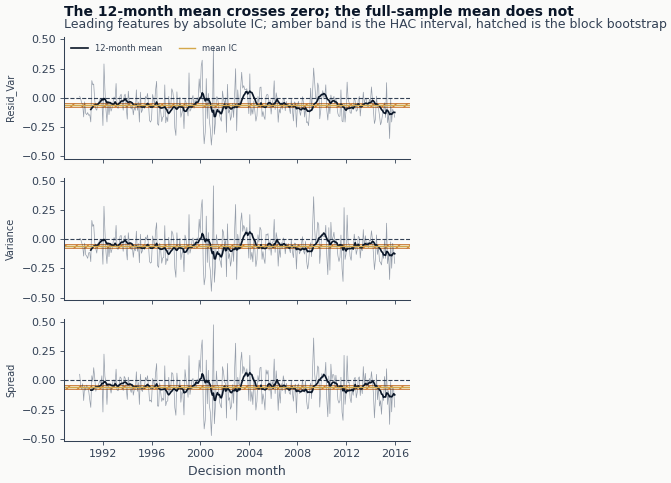

In [13]:
LEADING_FOR_SERIES = 3
series_features = eval_summary.head(LEADING_FOR_SERIES)["feature"].to_list()
ROLLING_MONTHS = 12

fig, axes = plt.subplots(
    len(series_features), 1, figsize=FIGSIZE["dual_v"], sharex=True, sharey=True
)
for ax, feat in zip(axes, series_features, strict=True):
    series = ic_timeseries[feat].sort(DATE_COL)
    bands = compute_ic_uncertainty(series, horizon=LABEL_HORIZON_MONTHS, ic_col="ic")
    dates = series[DATE_COL].to_list()
    ax.plot(dates, series["ic"].to_list(), color=COLORS["slate"], linewidth=0.5, alpha=0.45)
    ax.plot(
        dates,
        series["ic"].rolling_mean(ROLLING_MONTHS, min_samples=ROLLING_MONTHS).to_list(),
        color=COLORS["blue"],
        linewidth=1.2,
        label=f"{ROLLING_MONTHS}-month mean",
    )
    ax.axhline(bands["mean_ic"], color=COLORS["amber"], linewidth=1.0, label="mean IC")
    ax.axhspan(
        bands["ci_hac_lower"], bands["ci_hac_upper"], color=COLORS["amber"], alpha=0.25, lw=0
    )
    ax.axhspan(
        bands["ci_boot_lower"],
        bands["ci_boot_upper"],
        facecolor="none",
        edgecolor=COLORS["copper"],
        hatch="///",
        lw=0.6,
    )
    zero_line(ax)
    ax.set_ylabel(feat, fontsize=7)
axes[0].legend(frameon=False, fontsize=6, ncols=2, loc="upper left")
axes[-1].set_xlabel("Decision month")
add_message_title(
    axes[0],
    "The 12-month mean crosses zero; the full-sample mean does not",
    subtitle=(
        "Leading features by absolute IC; amber band is the HAC interval, "
        "hatched is the block bootstrap"
    ),
)
fig.tight_layout()
plt.show()

### IC Strength and HAC Adjustment

The first chart ranks the leading features by absolute IC. The second compares
naive and HAC t-statistics on equal axes.

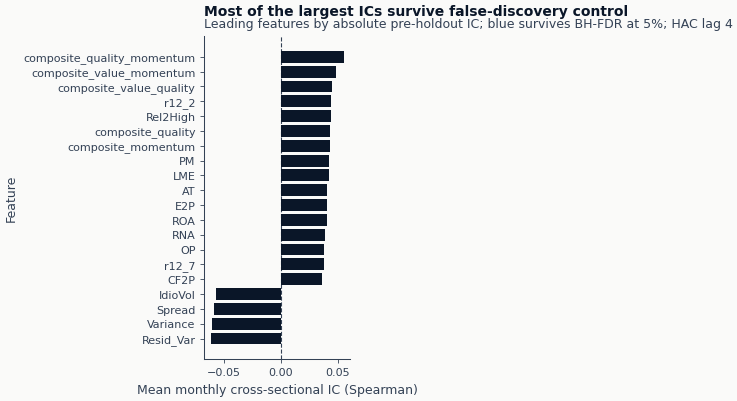

In [14]:
top_n = min(20, len(eval_summary))
top = eval_summary.head(top_n).sort("ic_mean")

fig, ax = plt.subplots(figsize=FIGSIZE["single_tall"])
bar_colors = [
    COLORS["blue"] if significant else COLORS["silver_muted"]
    for significant in top["fdr_sig"].to_list()
]
ax.barh(top["feature"].to_list(), top["ic_mean"].to_list(), color=bar_colors)
zero_line(ax, at=0, axis="x")
ax.set_xlabel("Mean monthly cross-sectional IC (Spearman)")
ax.set_ylabel("Feature")
add_message_title(
    ax,
    "Most of the largest ICs survive false-discovery control",
    subtitle=(
        f"Leading features by absolute pre-holdout IC; blue survives BH-FDR at "
        f"{FDR_ALPHA:.0%}; HAC lag {HAC_MAXLAGS}"
    ),
)
plt.show()

HAC inference changes the scale of the mean tests but not the underlying IC
estimates. Points below the diagonal have smaller HAC t-statistics.

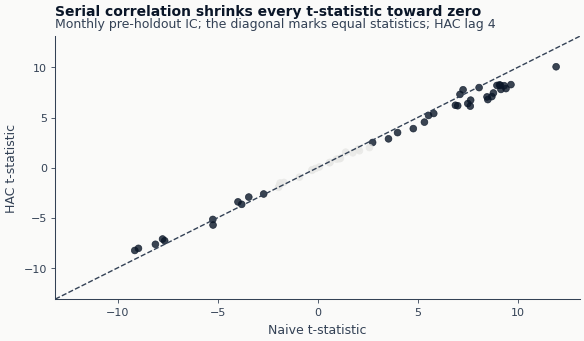

In [15]:
fig, ax = plt.subplots(figsize=FIGSIZE["single"])
point_colors = [
    COLORS["blue"] if significant else COLORS["silver_muted"]
    for significant in eval_summary["fdr_sig"].to_list()
]
ax.scatter(
    eval_summary["naive_t"].to_list(),
    eval_summary["hac_t"].to_list(),
    c=point_colors,
    s=24,
    alpha=0.8,
)
max_t = (
    max(
        eval_summary["naive_t"].cast(pl.Float64, strict=False).abs().max() or 1.0,
        eval_summary["hac_t"].cast(pl.Float64, strict=False).abs().max() or 1.0,
    )
    * 1.1
)
ax.plot(
    [-max_t, max_t],
    [-max_t, max_t],
    linestyle="--",
    color=COLORS["neutral"],
    linewidth=1,
)
ax.set_xlim(-max_t, max_t)
ax.set_ylim(-max_t, max_t)
ax.set_xlabel("Naive t-statistic")
ax.set_ylabel("HAC t-statistic")
add_message_title(
    ax,
    "Serial correlation shrinks every t-statistic toward zero",
    subtitle=f"Monthly pre-holdout IC; the diagonal marks equal statistics; HAC lag {HAC_MAXLAGS}",
)
plt.show()

**Interpretation**: a cross-section this wide gives the mean IC a small standard
error, so a small IC can still be significant, and significance stops being the
interesting question. HAC inference allows serial dependence in the monthly IC
series, and FDR controls the expected share of false discoveries among the
features declared significant across the whole searched set.

## Section 4: Shape Diagnostics

Quantile monotonicity analysis: does the label (1-month return) spread
monotonically across feature quintiles? A monotone relationship is easier
for linear models (Ch11) to capture; non-monotone relationships may need
tree-based models (Ch12). Quintiles are assigned **within each month**, so the
bin a firm lands in is its standing against the firms trading beside it and not
against a different month's distribution.

Two summaries of each bin are drawn, and they are the point of the figure. The
mean is what a long-short book earns; the median is where the typical firm in
that bin ends up. Under the return distribution of a wide equity cross-section
these two can point in opposite directions, because a handful of very large
positive returns move a mean and cannot move a median. Where they disagree, the
rank IC above agrees with the median, since it is also a rank statistic: a
feature can carry a clearly negative IC and still show a mean profile that
climbs from Q1 to Q5. `monotonicity` in the ledger is computed on the means,
which is the convention all nine case studies share, and it is a description of
the shape rather than an input to any triage rule.

In [16]:
top_features_for_shape = eval_summary.filter(pl.col("fdr_sig").fill_null(False))[
    "feature"
].to_list()[:15]

if not top_features_for_shape:
    top_features_for_shape = eval_summary.head(10)["feature"].to_list()

monotonicity_scores = {}
quantile_spreads = {}
for feat in top_features_for_shape:
    valid = eval_panel.select([DATE_COL, feat, label_col]).drop_nulls()
    if len(valid) < N_QUANTILES * 20:
        continue
    valid = valid.with_columns(
        ((pl.col(feat).rank("average").over(DATE_COL) - 1) * N_QUANTILES / pl.len().over(DATE_COL))
        .floor()
        .clip(0, N_QUANTILES - 1)
        .cast(pl.Int8)
        .alias("quantile_index")
    )
    # Each month contributes equally, which is how the IC series above is built and
    # how a monthly rebalance actually experiences the panel. Pooling every row
    # instead would weight months by their cross-section, and the cross-section
    # here grows by an order of magnitude over the sample.
    q_profile = (
        valid.group_by(DATE_COL, "quantile_index")
        .agg(
            pl.col(label_col).mean().alias("mean"),
            pl.col(label_col).median().alias("median"),
        )
        .group_by("quantile_index")
        .agg(pl.col("mean").mean(), pl.col("median").mean())
        .sort("quantile_index")
    )
    means = q_profile["mean"].to_list()
    medians = q_profile["median"].to_list()
    if len(means) != N_QUANTILES:
        continue
    spread = means[-1] - means[0]
    quantile_spreads[feat] = {"q_means": means, "q_medians": medians, "spread": spread}

    mono_corr, _ = spearmanr(range(len(means)), means)
    monotonicity_scores[feat] = float(mono_corr)

print(f"Quantile analysis for {len(quantile_spreads)} features")

Quantile analysis for 15 features


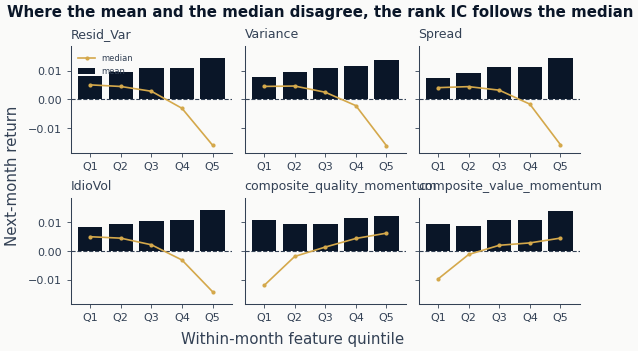

In [17]:
if quantile_spreads:
    n_show = min(6, len(quantile_spreads))
    feats_to_show = list(quantile_spreads.keys())[:n_show]
    all_values = [
        value
        for feature in feats_to_show
        for key in ("q_means", "q_medians")
        for value in quantile_spreads[feature][key]
    ]
    y_limit = max(abs(min(all_values)), abs(max(all_values))) * 1.15
    fig, axes = plt.subplots(2, 3, figsize=FIGSIZE["grid_2x3"], sharey=True)
    bins = [f"Q{i + 1}" for i in range(N_QUANTILES)]
    for idx, feat in enumerate(feats_to_show):
        ax = axes.flat[idx]
        ax.bar(bins, quantile_spreads[feat]["q_means"], color=COLORS["blue"], label="mean")
        ax.plot(
            bins,
            quantile_spreads[feat]["q_medians"],
            color=COLORS["amber"],
            marker="o",
            markersize=3,
            linewidth=1.2,
            label="median",
        )
        zero_line(ax)
        ax.set_ylim(-y_limit, y_limit)
        ax.set_title(feat, fontsize=9)
    axes.flat[0].legend(frameon=False, fontsize=6, loc="upper left")
    fig.supylabel("Next-month return")
    fig.supxlabel("Within-month feature quintile")
    fig.suptitle(
        "Where the mean and the median disagree, the rank IC follows the median",
        color=COLORS["blue"],
        fontweight="semibold",
        x=0.01,
        ha="left",
    )
    plt.show()

**Interpretation**: a monotone profile - steady increase or decrease from Q1 to
Q5 - is the shape a linear model in Ch11 can express, and a U-shaped or
inverted-U profile is the shape that needs the tree-based models in Ch12. Read
the two series together rather than either alone: a feature whose mean climbs
while its median falls is one whose payoff sits in the right tail of the top
bin, which is a different proposition to hold than a feature that lifts the
whole bin, and it is not something a single monotonicity score records.

## Section 5: Redundancy & Feature Families

Pairwise Spearman correlation matrix to identify redundant features,
and family-level IC aggregation to assess which categories contribute
most signal.

In [18]:
def assign_feature_family(feature_name: str) -> str:
    """Map feature name to family for US firm characteristics."""
    name = feature_name.lower()
    families = [
        # Composites and interactions first (prefix-based, must match before single-char)
        (["composite_"], "composite"),
        (["interaction_"], "interaction"),
        # Factor families
        (["beme", "e2p", "cf2p", "s2p", "d2p", "a2me"], "value"),
        (["roe", "roa", "prof", "op", "pcm", "pm", "ni", "sga2s", "fc2y", "rna"], "quality"),
        (["r12_", "r2_1", "r36_", "st_rev", "lt_rev", "rel2high", "suv"], "momentum"),
        (["beta", "idiovol", "variance", "resid_var", "mktbeta", "spread"], "risk"),
        (["investment", "dpi2a", "noa", "oa", "ac", "d2a"], "investment"),
        (["lme", "at", "q", "c", "cf", "lev", "ol", "cto", "ato", "lturnover"], "size_leverage"),
    ]
    for prefixes, family in families:
        if any(p in name for p in prefixes):
            return family
    return "other"

In [19]:
# Assign families
families = {feat: assign_feature_family(feat) for feat in all_feature_cols}

In [20]:
# Pairwise correlation (sample every Nth month for efficiency)
sample_step = max(1, n_dates // 200)
sample_dates = eval_panel[DATE_COL].unique().sort().to_list()[::sample_step]
corr_data = eval_panel.filter(pl.col(DATE_COL).is_in(sample_dates)).select(evaluable_features)
corr_matrix = corr_data.to_pandas().corr(method="spearman")

# Count high-correlation pairs
high_corr_pairs = []
for i in range(len(corr_matrix)):
    for j in range(i + 1, len(corr_matrix)):
        if abs(corr_matrix.iloc[i, j]) > REDUNDANCY_CUT:
            high_corr_pairs.append(
                (corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j])
            )

top_corr_pairs = sorted(high_corr_pairs, key=lambda item: abs(item[2]), reverse=True)[:15]
pair_summary = pl.DataFrame(
    {
        "pair": [f"{left} / {right}" for left, right, _ in top_corr_pairs],
        "correlation": [float(correlation) for _, _, correlation in top_corr_pairs],
    }
).sort("correlation")
print(f"Feature pairs with |corr| > {REDUNDANCY_CUT}: {len(high_corr_pairs)}")

Feature pairs with |corr| > 0.7: 42


In [21]:
# Family-level IC summary
family_ic: dict[str, list] = {}
fdr_sig_features = set(eval_summary.filter(pl.col("fdr_sig").fill_null(False))["feature"].to_list())
for feat in ic_results:
    fam = families.get(feat, "other")
    family_ic.setdefault(fam, []).append(
        {
            "feature": feat,
            "ic": ic_results[feat]["mean_ic"],
            "fdr_sig": feat in fdr_sig_features,
        }
    )

family_summary = {}
for fam, feats in sorted(family_ic.items()):
    ics = [f["ic"] for f in feats if f["ic"] is not None]
    n_sig = sum(1 for f in feats if f["fdr_sig"])
    family_summary[fam] = {
        "n_features": len(feats),
        "avg_abs_ic": float(np.mean([abs(ic) for ic in ics])) if ics else 0.0,
        "avg_ic": float(np.mean(ics)) if ics else 0.0,
        "n_fdr_sig": n_sig,
    }

if family_summary:
    fam_df = pl.DataFrame([{"family": fam, **stats} for fam, stats in family_summary.items()]).sort(
        "avg_abs_ic", descending=True
    )
else:
    fam_df = pl.DataFrame(
        schema={
            "family": pl.Utf8,
            "n_features": pl.Int64,
            "avg_abs_ic": pl.Float64,
            "avg_ic": pl.Float64,
            "n_fdr_sig": pl.Int64,
        }
    )

### Redundancy and Family Strength

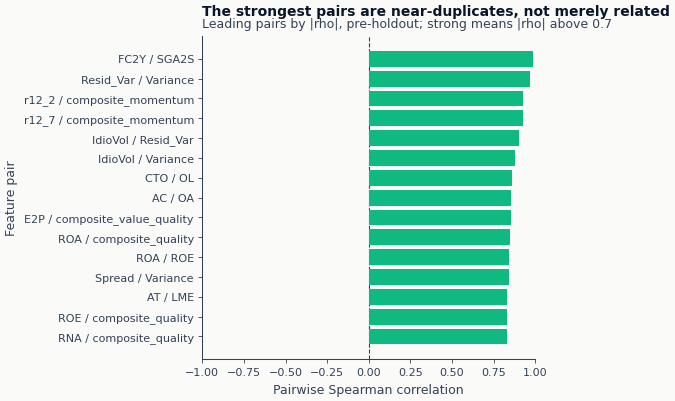

In [22]:
fig, ax = plt.subplots(figsize=FIGSIZE["single_tall"])
pair_colors = [
    COLORS["positive"] if value >= 0 else COLORS["negative"]
    for value in pair_summary["correlation"].to_list()
]
ax.barh(
    pair_summary["pair"].to_list(),
    pair_summary["correlation"].to_list(),
    color=pair_colors,
)
zero_line(ax, at=0, axis="x")
ax.set_xlim(-1, 1)
ax.set_xlabel("Pairwise Spearman correlation")
ax.set_ylabel("Feature pair")
add_message_title(
    ax,
    "The strongest pairs are near-duplicates, not merely related",
    subtitle=f"Leading pairs by |rho|, pre-holdout; strong means |rho| above {REDUNDANCY_CUT}",
)
plt.show()

Family averages show where predictive strength is concentrated without treating
a family mean as an independent significance test.

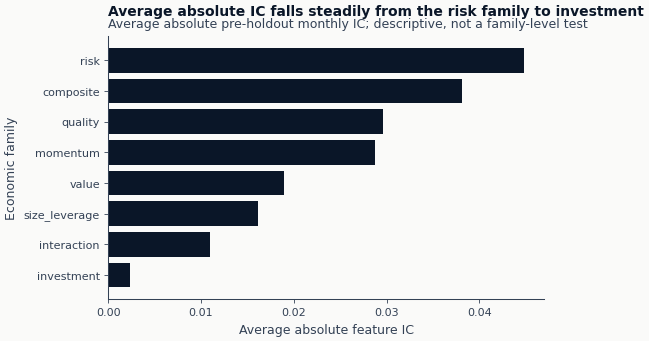

In [23]:
plot_families = fam_df.sort("avg_abs_ic")
fig, ax = plt.subplots(figsize=FIGSIZE["single"])
ax.barh(
    plot_families["family"].to_list(),
    plot_families["avg_abs_ic"].to_list(),
    color=COLORS["blue"],
)
ax.set_xlabel("Average absolute feature IC")
ax.set_ylabel("Economic family")
add_message_title(
    ax,
    "Average absolute IC falls steadily from the risk family to investment",
    subtitle="Average absolute pre-holdout monthly IC; descriptive, not a family-level test",
)
plt.show()

**Interpretation**: Value, quality, and size features form correlated clusters,
expected from the factor literature. The composite features are intentionally
constructed from these clusters, so high within-family correlation is by design.
Regularized linear and tree-based models provide complementary ways to manage
this redundancy downstream.

## Section 6: Triage & Handoff

Apply triage rules to categorize features for Ch11 model selection:

| Decision | Criteria | Arm |
|----------|----------|-----|
| **PROCEED** | BH-FDR significant at `FDR_ALPHA` | confirmation |
| **PROCEED** | sign consistency at least `MIN_SIGN_CONSISTENCY` and abs(IC) at least `IC_THRESHOLD` | exploration |
| **STOP** | correctness FAIL: coverage below `MIN_COVERAGE` | - |
| **REVISE** | everything else, to be judged in the multivariate context of Ch11 | - |

The rule is a **disjunction**, so PROCEED can exceed the count of FDR-significant
features. The `note` column records which of the two arms fired. The second arm is
an exploration filter in the sense of Section 7.4, not a significance test: it exists
so that false-discovery control does not empty the menu, and a feature promoted
through it has not been confirmed. Its threshold is a judgement, stated in
Configuration as `IC_THRESHOLD` and tied to what a monthly rebalance would need to
clear its costs, not derived from the data.

In [24]:
triage = {}
for feat in all_feature_cols:
    if not correctness[feat]:
        triage[feat] = ("STOP", "correctness_fail")
        continue

    if feat not in ic_results:
        triage[feat] = ("REVISE", "insufficient_data")
        continue

    is_fdr_sig = feat in fdr_sig_features
    sign_con = fold_stats.get(feat, {}).get("sign_consistency", 0)
    abs_ic = abs(ic_results[feat]["mean_ic"])

    if is_fdr_sig:
        triage[feat] = ("PROCEED", "fdr_significant")
    elif sign_con >= MIN_SIGN_CONSISTENCY and abs_ic >= IC_THRESHOLD:
        triage[feat] = ("PROCEED", "stable_and_above_threshold")
    else:
        triage[feat] = ("REVISE", "not_significant_standalone")

### Build Triage Ledger

In [25]:
ledger_rows = []
for feat in all_feature_cols:
    decision, note = triage[feat]
    row = {
        "feature": feat,
        "family": families.get(feat, "other"),
        "source": "financial",
        "ic_mean": ic_results.get(feat, {}).get("mean_ic"),
        "hac_t": ic_results.get(feat, {}).get("t_stat"),
        "hac_p": ic_results.get(feat, {}).get("p_value"),
        "fdr_p": None,
        "fdr_sig": False,
        "sign_consistency": fold_stats.get(feat, {}).get("sign_consistency"),
        "worst_fold_ic": fold_stats.get(feat, {}).get("worst_fold_ic"),
        "monotonicity": monotonicity_scores.get(feat),
        "coverage": coverage[feat],
        "decision": decision,
        "note": note,
    }
    match = eval_summary.filter(pl.col("feature") == feat)
    if len(match) > 0:
        row["fdr_p"] = match["fdr_p"][0]
        row["fdr_sig"] = bool(match["fdr_sig"][0])
    ledger_rows.append(row)

triage_ledger = pl.DataFrame(ledger_rows)
triage_ledger.write_parquet(EVAL_DIR / "triage_ledger.parquet")

print(f"Triage ledger: {display_path(EVAL_DIR / 'triage_ledger.parquet')}")
print(triage_ledger.group_by("decision").len().sort("decision"))

Triage ledger: case_studies/us_firm_characteristics/evaluation/triage_ledger.parquet
shape: (2, 2)
┌──────────┬─────┐
│ decision ┆ len │
│ ---      ┆ --- │
│ str      ┆ u32 │
╞══════════╪═════╡
│ PROCEED  ┆ 40  │
│ REVISE   ┆ 17  │
└──────────┴─────┘


### Save IC Time Series

In [26]:
ic_ts_frames = []
for feat, ts in ic_timeseries.items():
    ic_ts_frames.append(ts.with_columns(pl.lit(feat).alias("feature")))

if ic_ts_frames:
    ic_ts_all = pl.concat(ic_ts_frames)
    ic_ts_all.write_parquet(EVAL_DIR / "ic_timeseries.parquet")
    print(f"IC time series: {len(ic_ts_all):,} rows, {ic_ts_all['feature'].n_unique()} features")

IC time series: 17,784 rows, 57 features


### Summarize the Triage Decision

In [27]:
proceed_features = [f for f, (d, _) in triage.items() if d == "PROCEED"]
revise_features = [f for f, (d, _) in triage.items() if d == "REVISE"]
stop_features = [f for f, (d, _) in triage.items() if d == "STOP"]

In [28]:
print(f"PROCEED: {len(proceed_features)} features")
print(f"REVISE: {len(revise_features)} features")
print(f"STOP: {len(stop_features)} features")

promoted_summary = (
    triage_ledger.filter(pl.col("decision") == "PROCEED")
    .select("feature", "family", "ic_mean", "hac_t", "fdr_sig", "sign_consistency", "note")
    .sort("ic_mean", descending=True)
)
print(promoted_summary.group_by("note").len().sort("note"))

PROCEED: 40 features
REVISE: 17 features
STOP: 0 features
shape: (2, 2)
┌────────────────────────────┬─────┐
│ note                       ┆ len │
│ ---                        ┆ --- │
│ str                        ┆ u32 │
╞════════════════════════════╪═════╡
│ fdr_significant            ┆ 38  │
│ stable_and_above_threshold ┆ 2   │
└────────────────────────────┴─────┘


The funnel is what the searched set costs. Every candidate that clears coverage
gets an IC; the confirmation arm keeps the ones that survive BH-FDR over the
whole searched set; the exploration arm adds the ones whose sign holds across
folds at an effect size worth a monthly rebalance. The two arms are drawn apart
because a reader who sees only the total cannot tell how much of the menu was
confirmed and how much was carried forward on stability alone.

/tmp/ipykernel_2383897/1636984356.py:29: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


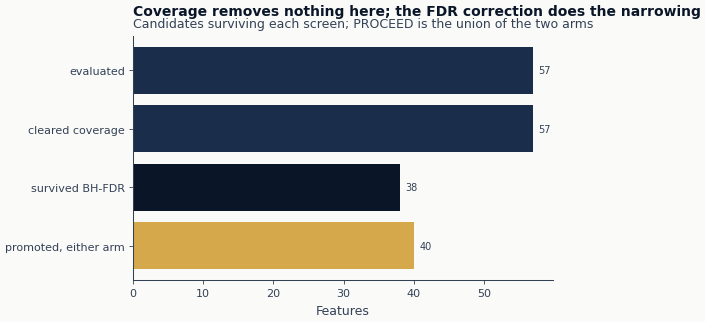

In [29]:
funnel = [
    ("evaluated", len(all_feature_cols)),
    ("cleared coverage", len(ic_results)),
    ("survived BH-FDR", len(fdr_sig_features)),
    ("promoted, either arm", len(proceed_features)),
]
fig, ax = plt.subplots(figsize=FIGSIZE["single"])
stage_labels = [name for name, _ in funnel]
counts = [count for _, count in funnel]
ax.barh(
    stage_labels, counts, color=[COLORS["slate"], COLORS["slate"], COLORS["blue"], COLORS["amber"]]
)
for row, count in enumerate(counts):
    ax.annotate(
        str(count),
        xy=(count, row),
        xytext=(4, 0),
        textcoords="offset points",
        va="center",
        fontsize=7,
    )
ax.invert_yaxis()
ax.set_xlabel("Features")
add_message_title(
    ax,
    "Coverage removes nothing here; the FDR correction does the narrowing",
    subtitle="Candidates surviving each screen; PROCEED is the union of the two arms",
)
fig.tight_layout()
plt.show()

### What the ledger says, and what it does not

The per-feature decision above is the output of this notebook. It is not a
judgement on the case study: a univariate screen is necessary and not sufficient,
and whether any of this is tradable is settled by a backtest several stages later.
What the broad monthly cross-section buys is statistical power, which is why
effect size, fold stability and multiplicity all have to enter the rule rather
than significance alone.

## Key Takeaways

1. **Large breadth drives significance**: across a cross-section this wide,
   even modest IC values achieve statistical significance, which is why the
   searched-set size and the FDR correction have to be reported beside any
   p-value in this factor zoo.

2. **Composite features are competitive**: Cross-family combinations appear
   among the stronger IC estimates, but correlated inputs mean downstream
   regularization remains important.

3. **Economic families differ**: Momentum, profitability, size, and risk
   characteristics contribute signals with different signs and redundancy
   patterns; predictive IC does not establish causality.

4. **Identity supports longitudinal validation**: Anonymous symbols persist
   within the released source block, so fold stability and downstream firm
   histories are meaningful even though the public archive omits PERMNO.

**Next**: The triage ledger above defines the feature list for Ch11
Ridge/Lasso modeling.
**Book**: Section 7.3 and Section 7.4 set out univariate screening and search
accounting.